<a href="https://colab.research.google.com/github/kanchandhole/Data-Scientist/blob/main/07_April_Support_Vector_Machines_2_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Science Masters

In [1]:
#  GLOBAL IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import seaborn as sns
import warnings, joblib, os
warnings.filterwarnings('ignore')

# Sklearn — datasets
from sklearn.datasets import load_wine, make_classification, make_regression
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    cross_val_score, StratifiedKFold
)
# Sklearn — preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
# Sklearn — SVM
from sklearn.svm import SVC, SVR
# Sklearn — metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.pipeline import Pipeline

# Plot defaults
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#F8F9FA',
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 12,
})

SEED = 42
np.random.seed(SEED)
print("✓ All libraries imported successfully!")
import sklearn; print(f"  scikit-learn : {sklearn.__version__}")
print(f"  numpy        : {np.__version__}")
print(f"  pandas       : {pd.__version__}")

✓ All libraries imported successfully!
  scikit-learn : 1.6.1
  numpy        : 2.0.2
  pandas       : 2.2.2


---
## Q1. Polynomial Functions & Kernel Functions in Machine Learning

### 1.1 The Core Problem: Non-Linearly Separable Data

Standard SVMs find a **linear hyperplane** to separate classes. But many real-world datasets are **not linearly separable** in the original feature space.

**Solution**: Map data to a **higher-dimensional space** where linear separation becomes possible.

```
Original Space (2D)         Higher-Dimensional Space (3D)
    ○ ● ○ ● (mixed)    →       ○ ○ ○  (separable by plane)
                                  ───────────
                                ● ● ●
```

### 1.2 The Kernel Trick
Explicitly computing the mapping $\phi(x)$ is computationally expensive. Instead, we use the **kernel trick**:

$$K(x_i, x_j) = \phi(x_i)^T \cdot \phi(x_j)$$

The kernel function computes the **dot product in the high-dimensional space** *without* explicitly computing $\phi(x)$.

### 1.3 Polynomial Kernel
The polynomial kernel of degree $d$ is defined as:

$$K_{\text{poly}}(x_i, x_j) = (\gamma \cdot x_i^T x_j + r)^d$$

where:
- $d$ = degree of polynomial
- $\gamma$ = scale factor (default: $1/n_{features}$)
- $r$ = coef0 — controls influence of higher vs lower degree terms

**Example** (degree=2, $\gamma$=1, $r$=0, features $x=[x_1, x_2]$):

$$K(x_i, x_j) = (x_i^T x_j)^2 = (x_{i1}x_{j1} + x_{i2}x_{j2})^2$$

This is equivalent to mapping:
$$\phi(x) = [x_1^2,\ \sqrt{2}x_1 x_2,\ x_2^2]$$

### 1.4 Common Kernel Functions

| Kernel | Formula | Use Case |
|--------|---------|----------|
| **Linear** | $x_i^T x_j$ | Linearly separable data |
| **Polynomial** | $(\gamma x_i^T x_j + r)^d$ | Curved boundaries, text classification |
| **RBF (Gaussian)** | $\exp(-\gamma \|x_i - x_j\|^2)$ | General purpose, non-linear |
| **Sigmoid** | $\tanh(\gamma x_i^T x_j + r)$ | Neural network-like |

### 1.5 Key Relationship
> A **polynomial kernel of degree $d$** implicitly maps data to a feature space containing **all polynomial combinations of features up to degree $d$**, enabling the SVM to learn polynomial decision boundaries — *without the computational cost of explicit mapping*.

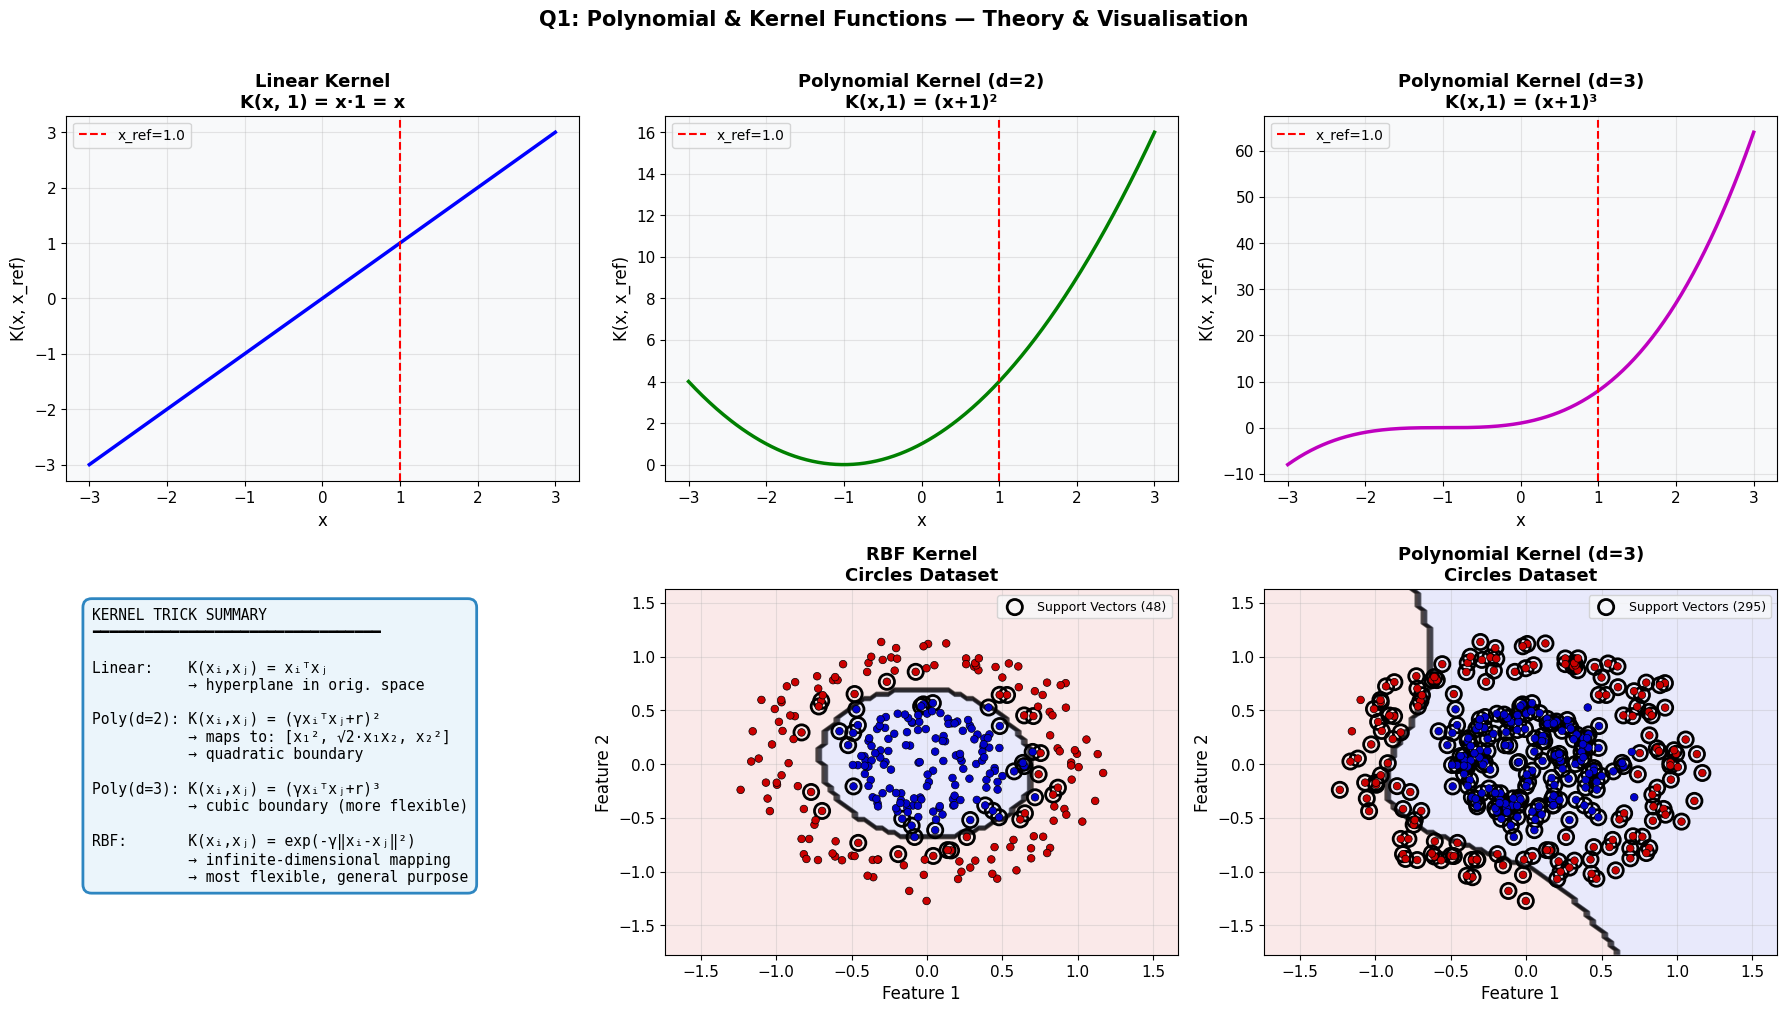

Q1 visualisation saved.


In [2]:
# Q1: Visualising Kernel Functions & Feature Mapping

# 1-D illustration: how polynomial kernel expands feature space
x = np.linspace(-3, 3, 400)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ── Row 1: Kernel Function Values K(x, x_ref) for varying x ──
x_ref = 1.0
gamma = 1.0

# Linear kernel
K_linear = x * x_ref
axes[0,0].plot(x, K_linear, 'b-', linewidth=2.5)
axes[0,0].axvline(x_ref, color='red', linestyle='--', label=f'x_ref={x_ref}')
axes[0,0].set_title('Linear Kernel\nK(x, 1) = x·1 = x', fontweight='bold')
axes[0,0].set_xlabel('x'); axes[0,0].set_ylabel('K(x, x_ref)')
axes[0,0].legend(fontsize=10)

# Polynomial kernel degree 2
K_poly2 = (gamma * x * x_ref + 1) ** 2
axes[0,1].plot(x, K_poly2, 'g-', linewidth=2.5)
axes[0,1].axvline(x_ref, color='red', linestyle='--', label=f'x_ref={x_ref}')
axes[0,1].set_title('Polynomial Kernel (d=2)\nK(x,1) = (x+1)²', fontweight='bold')
axes[0,1].set_xlabel('x'); axes[0,1].set_ylabel('K(x, x_ref)')
axes[0,1].legend(fontsize=10)

# Polynomial kernel degree 3
K_poly3 = (gamma * x * x_ref + 1) ** 3
axes[0,2].plot(x, K_poly3, 'm-', linewidth=2.5)
axes[0,2].axvline(x_ref, color='red', linestyle='--', label=f'x_ref={x_ref}')
axes[0,2].set_title('Polynomial Kernel (d=3)\nK(x,1) = (x+1)³', fontweight='bold')
axes[0,2].set_xlabel('x'); axes[0,2].set_ylabel('K(x, x_ref)')
axes[0,2].legend(fontsize=10)

# ── Row 2: 2D Decision Boundary comparison ──
from sklearn.datasets import make_circles, make_moons

X_circ, y_circ = make_circles(n_samples=300, noise=0.12, factor=0.4, random_state=SEED)
X_moon, y_moon = make_moons(n_samples=300, noise=0.15, random_state=SEED)

datasets = [(X_circ, y_circ, 'Circles (Non-linear)'),
            (X_moon, y_moon, 'Moons (Non-linear)')]
kernels  = ['rbf', 'poly']
k_labels = ['RBF Kernel', 'Polynomial Kernel (d=3)']

h = 0.04
cmap_bg = ListedColormap(['#FFCCCC','#CCCCFF'])
cmap_pt = ListedColormap(['#CC0000','#0000CC'])

for col_idx, (kern, klabel) in enumerate(zip(kernels, k_labels)):
    X_d, y_d, _ = datasets[0]
    svm = SVC(kernel=kern, degree=3, C=1.0, gamma='scale')
    svm.fit(X_d, y_d)

    x0_min, x0_max = X_d[:,0].min()-0.5, X_d[:,0].max()+0.5
    x1_min, x1_max = X_d[:,1].min()-0.5, X_d[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x0_min, x0_max, h),
                         np.arange(x1_min, x1_max, h))
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax = axes[1, col_idx+1]
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg)
    ax.contour(xx, yy, Z, colors='black', linewidths=1.2, alpha=0.5)
    sv = svm.support_vectors_
    ax.scatter(sv[:,0], sv[:,1], s=120, facecolors='none',
               edgecolors='k', linewidths=2, zorder=4, label=f'Support Vectors ({len(sv)})')
    ax.scatter(X_d[:,0], X_d[:,1], c=y_d, cmap=cmap_pt,
               edgecolors='k', s=30, linewidth=0.5, zorder=5)
    ax.set_title(f'{klabel}\nCircles Dataset', fontweight='bold')
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
    ax.legend(fontsize=9)

# Kernel comparison explanation
axes[1,0].axis('off')
info_text = (
    "KERNEL TRICK SUMMARY\n"
    "━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n\n"
    "Linear:    K(xᵢ,xⱼ) = xᵢᵀxⱼ\n"
    "           → hyperplane in orig. space\n\n"
    "Poly(d=2): K(xᵢ,xⱼ) = (γxᵢᵀxⱼ+r)²\n"
    "           → maps to: [x₁², √2·x₁x₂, x₂²]\n"
    "           → quadratic boundary\n\n"
    "Poly(d=3): K(xᵢ,xⱼ) = (γxᵢᵀxⱼ+r)³\n"
    "           → cubic boundary (more flexible)\n\n"
    "RBF:       K(xᵢ,xⱼ) = exp(-γ‖xᵢ-xⱼ‖²)\n"
    "           → infinite-dimensional mapping\n"
    "           → most flexible, general purpose"
)
axes[1,0].text(0.05, 0.95, info_text, transform=axes[1,0].transAxes,
               fontsize=10.5, verticalalignment='top', fontfamily='monospace',
               bbox=dict(boxstyle='round,pad=0.6', facecolor='#EBF5FB',
                         edgecolor='#2E86C1', linewidth=2))

fig.suptitle('Q1: Polynomial & Kernel Functions — Theory & Visualisation',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('q1_kernel_functions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Q1 visualisation saved.")

---
## Q2. Implementing SVM with Polynomial Kernel in Python (Scikit-learn)

### Polynomial Kernel Parameters in `sklearn.svm.SVC`

```python
SVC(kernel='poly',
    degree=3,        # d — polynomial degree
    gamma='scale',   # γ — scale factor
    coef0=0.0,       # r — independent term
    C=1.0)           # regularisation
```

$$K(x_i, x_j) = (\gamma \cdot x_i^T x_j + \text{coef0})^{\text{degree}}$$

### Effect of Each Parameter

| Parameter | Low Value | High Value |
|---|---|---|
| `degree` | Simpler boundary (linear-like) | More complex curved boundary |
| `C` | Wider margin, more misclassifications | Narrower margin, fewer misclassifications |
| `gamma` | Broad influence of each point | Local influence (overfits easily) |
| `coef0` | Lower-degree terms less important | Higher-degree terms more important |

  SVM POLYNOMIAL KERNEL — DEGREE COMPARISON (Moons)
  Degree      Train Acc   Test Acc   Support Vecs
  ------------------------------------------------
  1              0.8100     0.9200            118
  2              0.8200     0.9200            115
  3              0.9633     0.9800             69
  5              0.9867     0.9400             40

  C value       Train Acc   Test Acc   Support Vecs
  --------------------------------------------------
  C=0.01           0.8300     0.9500            163
  C=0.1            0.9133     0.9800            108
  C=10             0.9833     0.9500             35
  C=100            0.9833     0.9400             24


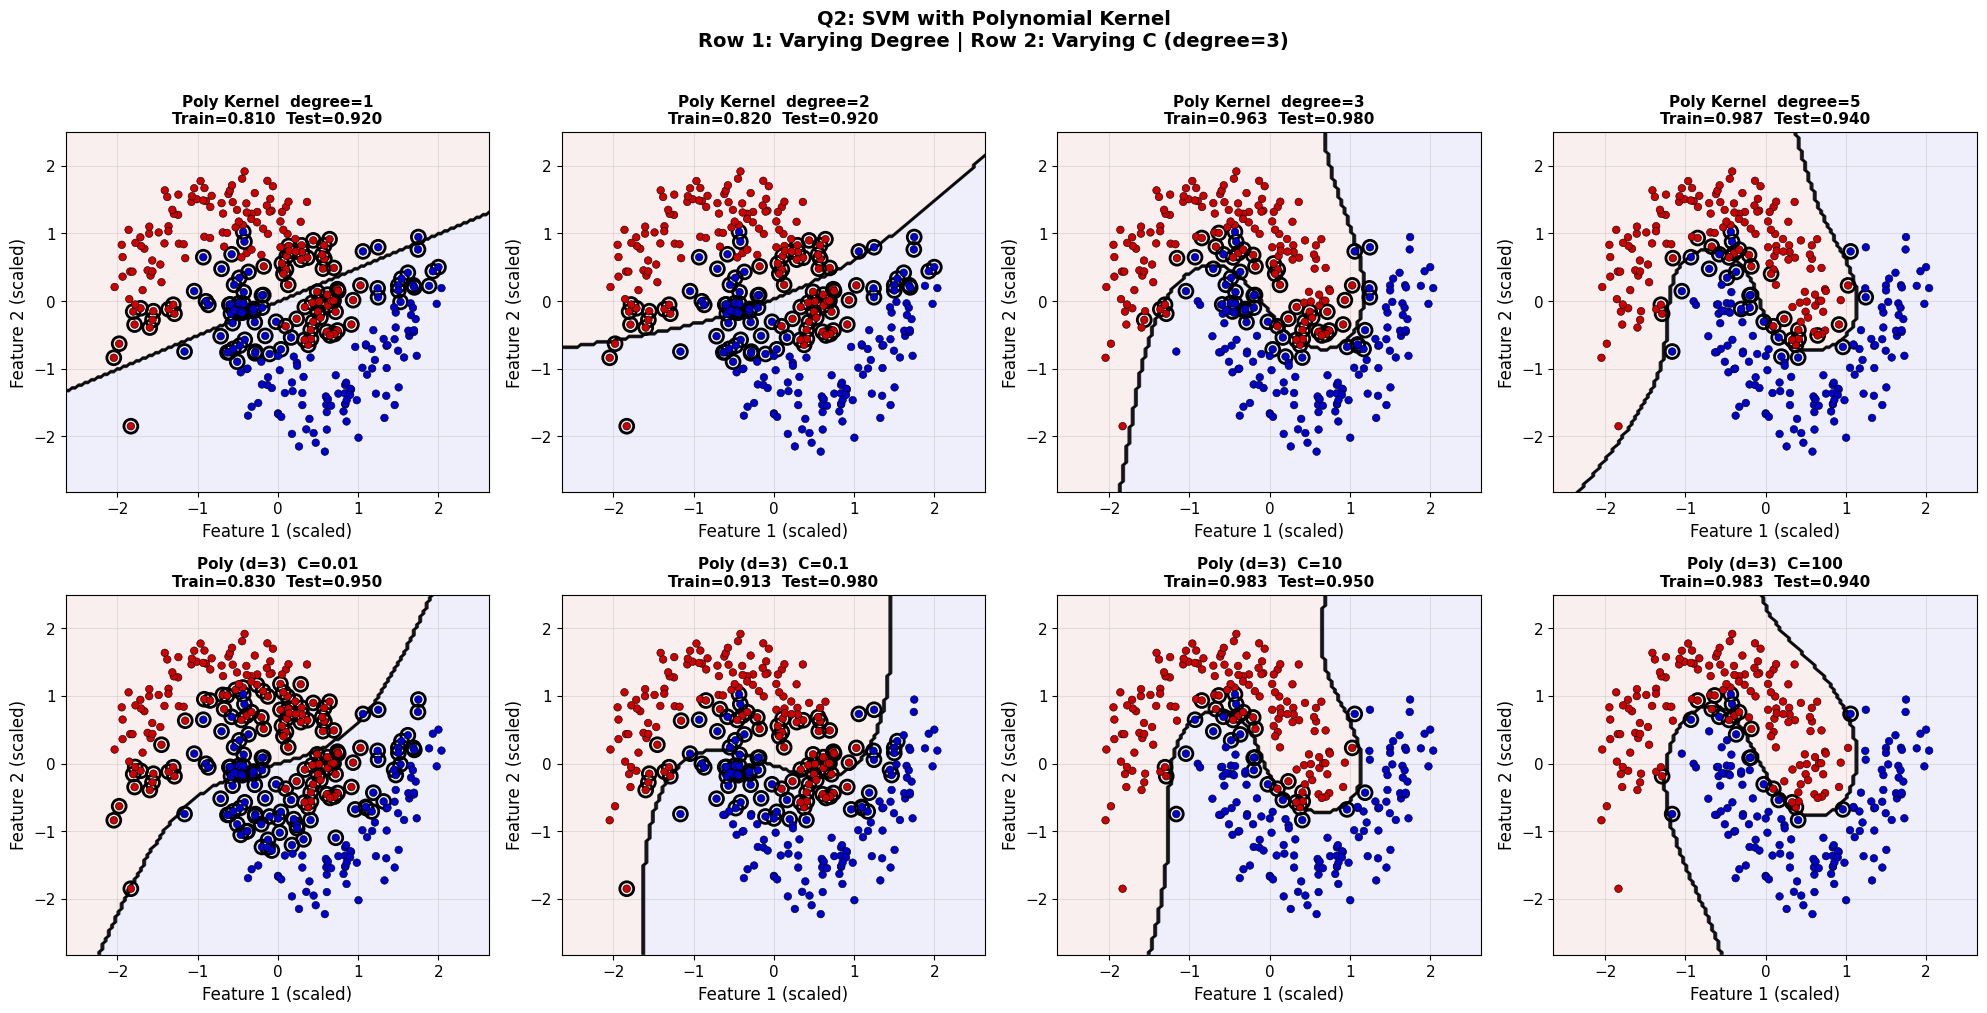

Q2 visualisation saved.


In [3]:
# Q2: SVM with Polynomial Kernel — Full Implementation

from sklearn.datasets import make_moons

# Generate a non-linearly separable dataset
X_q2, y_q2 = make_moons(n_samples=400, noise=0.20, random_state=SEED)
X_q2_tr, X_q2_te, y_q2_tr, y_q2_te = train_test_split(
    X_q2, y_q2, test_size=0.25, random_state=SEED, stratify=y_q2)

# Scale features (important for SVM)
scaler_q2 = StandardScaler()
X_q2_tr_s = scaler_q2.fit_transform(X_q2_tr)
X_q2_te_s = scaler_q2.transform(X_q2_te)

# Compare polynomial degrees
degrees = [1, 2, 3, 5]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

h  = 0.04
x0_min, x0_max = X_q2_tr_s[:,0].min()-0.6, X_q2_tr_s[:,0].max()+0.6
x1_min, x1_max = X_q2_tr_s[:,1].min()-0.6, X_q2_tr_s[:,1].max()+0.6
xx, yy = np.meshgrid(np.arange(x0_min, x0_max, h),
                     np.arange(x1_min, x1_max, h))

cmap_bg2 = ListedColormap(['#FFDDDD','#DDDDFF'])
cmap_pt2 = ListedColormap(['#CC0000','#0000CC'])

print("=" * 58)
print("  SVM POLYNOMIAL KERNEL — DEGREE COMPARISON (Moons)")
print("=" * 58)
print(f"  {'Degree':<10} {'Train Acc':>10} {'Test Acc':>10} {'Support Vecs':>14}")
print("  " + "-" * 48)

results_q2 = []
for col, deg in enumerate(degrees):
    svm_poly = SVC(kernel='poly', degree=deg, C=1.0,
                   gamma='scale', coef0=1.0, random_state=SEED)
    svm_poly.fit(X_q2_tr_s, y_q2_tr)

    tr_acc = svm_poly.score(X_q2_tr_s, y_q2_tr)
    te_acc = svm_poly.score(X_q2_te_s, y_q2_te)
    n_sv   = svm_poly.n_support_.sum()
    results_q2.append((deg, tr_acc, te_acc, n_sv))
    print(f"  {deg:<10} {tr_acc:>10.4f} {te_acc:>10.4f} {n_sv:>14}")

    # Decision boundary
    Z = svm_poly.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax = axes[0, col]
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg2)
    ax.contour(xx, yy, Z, colors='black', linewidths=1, alpha=0.6)
    sv = svm_poly.support_vectors_
    ax.scatter(sv[:,0], sv[:,1], s=100, facecolors='none',
               edgecolors='k', linewidths=2, zorder=4)
    ax.scatter(X_q2_tr_s[:,0], X_q2_tr_s[:,1], c=y_q2_tr,
               cmap=cmap_pt2, edgecolors='k', s=30, linewidth=0.4, zorder=5)
    ax.set_title(f'Poly Kernel  degree={deg}\nTrain={tr_acc:.3f}  Test={te_acc:.3f}',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Feature 1 (scaled)')
    ax.set_ylabel('Feature 2 (scaled)')

print("=" * 58)

# ── Row 2: Effect of C parameter (degree=3) ──
C_vals = [0.01, 0.1, 10, 100]
print(f"\n  {'C value':<12} {'Train Acc':>10} {'Test Acc':>10} {'Support Vecs':>14}")
print("  " + "-" * 50)
for col, C_val in enumerate(C_vals):
    svm_C = SVC(kernel='poly', degree=3, C=C_val,
                gamma='scale', coef0=1.0, random_state=SEED)
    svm_C.fit(X_q2_tr_s, y_q2_tr)
    tr_acc = svm_C.score(X_q2_tr_s, y_q2_tr)
    te_acc = svm_C.score(X_q2_te_s, y_q2_te)
    n_sv   = svm_C.n_support_.sum()
    print(f"  C={C_val:<10} {tr_acc:>10.4f} {te_acc:>10.4f} {n_sv:>14}")

    Z = svm_C.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax2 = axes[1, col]
    ax2.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg2)
    ax2.contour(xx, yy, Z, colors='black', linewidths=1, alpha=0.6)
    sv2 = svm_C.support_vectors_
    ax2.scatter(sv2[:,0], sv2[:,1], s=100, facecolors='none',
                edgecolors='k', linewidths=2, zorder=4)
    ax2.scatter(X_q2_tr_s[:,0], X_q2_tr_s[:,1], c=y_q2_tr,
                cmap=cmap_pt2, edgecolors='k', s=30, linewidth=0.4, zorder=5)
    ax2.set_title(f'Poly (d=3)  C={C_val}\nTrain={tr_acc:.3f}  Test={te_acc:.3f}',
                  fontweight='bold', fontsize=11)
    ax2.set_xlabel('Feature 1 (scaled)')
    ax2.set_ylabel('Feature 2 (scaled)')

fig.suptitle('Q2: SVM with Polynomial Kernel\n'
             'Row 1: Varying Degree | Row 2: Varying C (degree=3)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('q2_poly_kernel_svm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Q2 visualisation saved.")

---
## Q3. How Epsilon (ε) Affects Support Vectors in SVR

### SVR — The ε-Insensitive Tube

In **Support Vector Regression (SVR)**, the algorithm fits a function $f(x)$ such that:
- All training points **within** $\epsilon$ of the true value are **not penalised**
- Points **outside** the $\epsilon$-tube contribute to the loss

$$\text{Loss} = \max(0,\ |y - f(x)| - \epsilon)$$

The **ε-insensitive tube** is a band of width $2\epsilon$ around the regression line.

### SVR Objective
$$\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + C\sum_{i=1}^n (\xi_i + \xi_i^*)$$

subject to $|y_i - f(x_i)| \leq \epsilon + \xi_i$

### How ε Controls Support Vectors

| ε Value | Tube Width | Support Vectors | Behaviour |
|---------|-----------|-----------------|----------|
| **Small ε** | Narrow tube | **Many SVs** | More sensitive, follows data closely |
| **Large ε** | Wide tube | **Few SVs** | More generalised, smoother function |
| ε = 0 | No tube | Maximum SVs | Like standard regression |
| ε → ∞ | Infinite tube | 0 SVs | Flat line (all points inside tube) |

### Key Insight
> Increasing ε **increases the tolerance** for prediction errors, causing more training points to fall inside the tube → **fewer support vectors** → **simpler, smoother model**.

  SVR: EPSILON vs SUPPORT VECTORS
  Epsilon         n_SVs   R² Score
  ----------------------------------
  ε=0.05             67     0.9462
  ε=0.2              32     0.9451
  ε=0.5              10     0.9123
  ε=1.0               5     0.6715


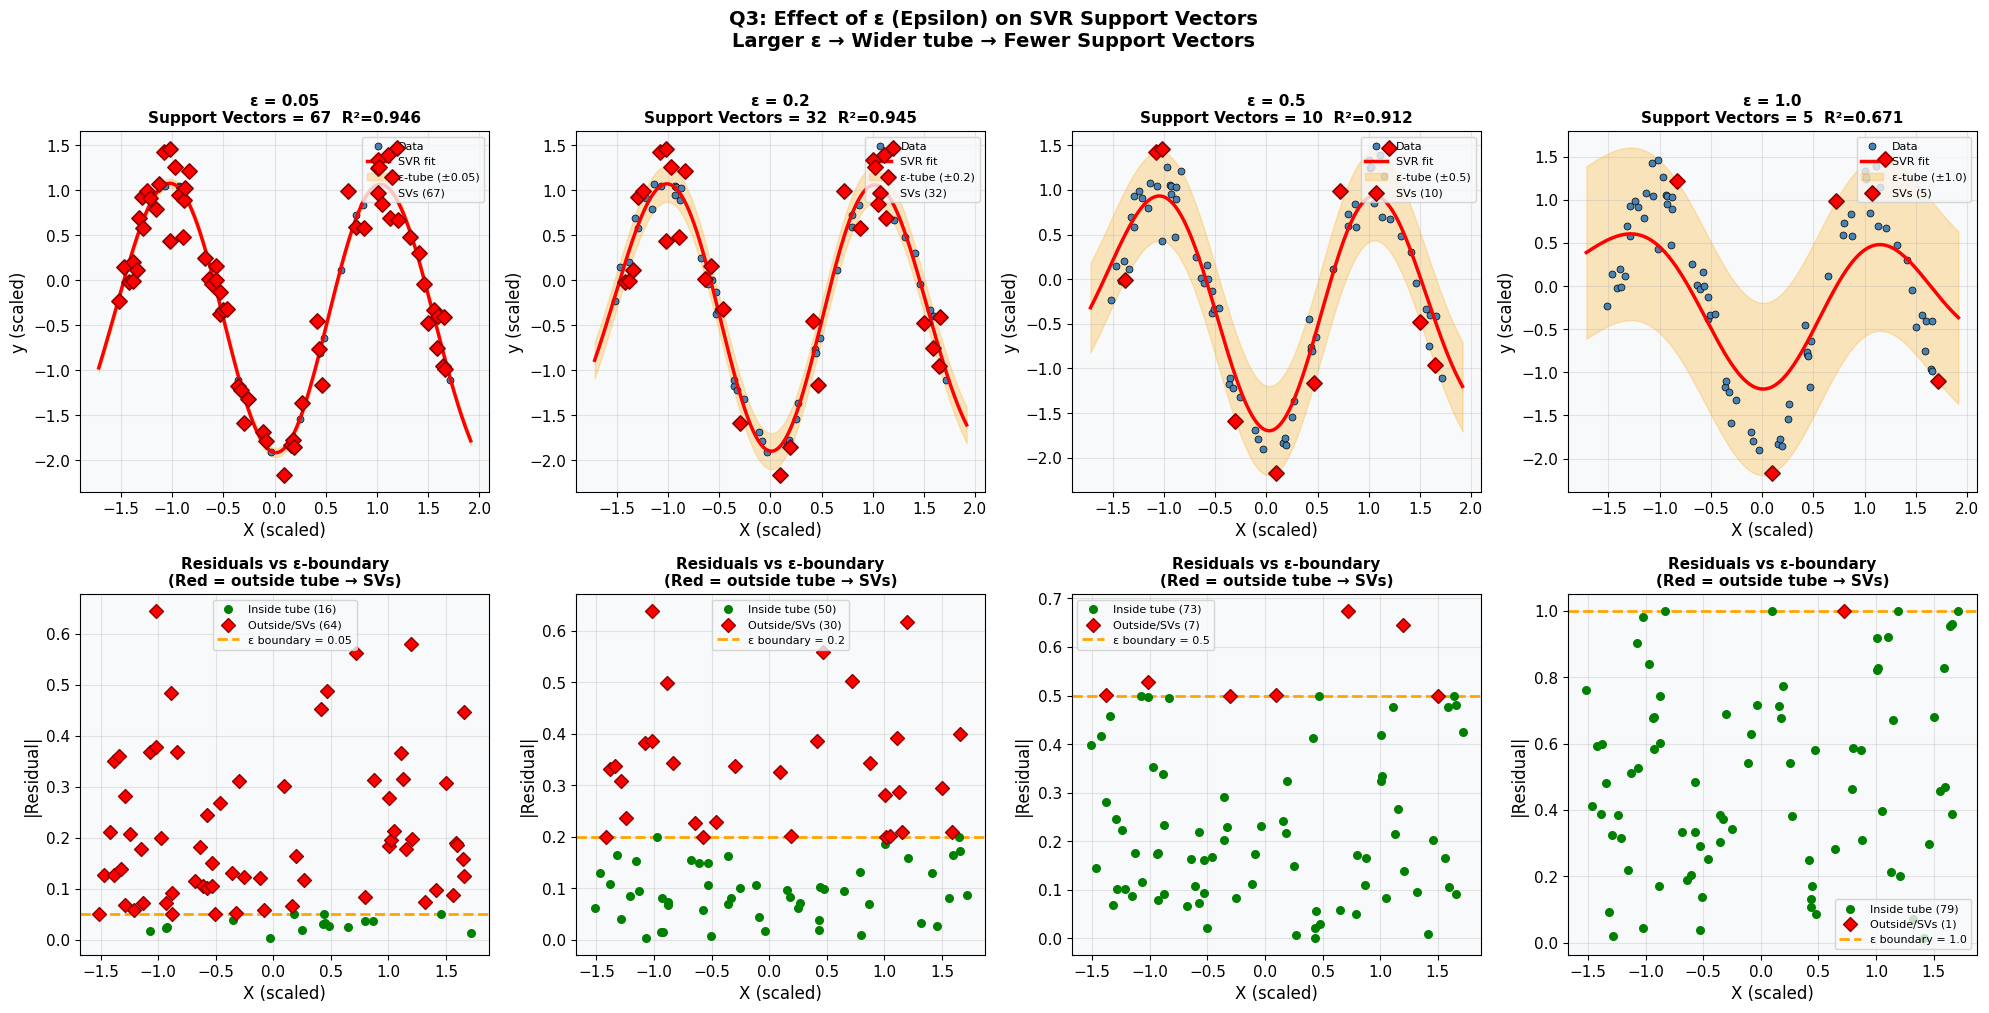

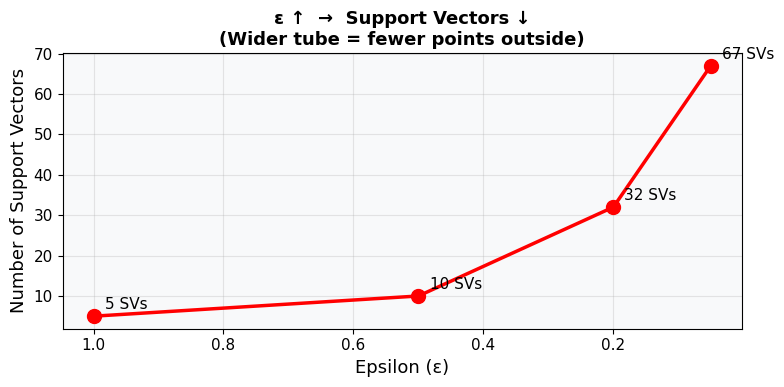

Q3 visualisations saved.


In [4]:
# Q3: Epsilon Effect on SVR Support Vectors

np.random.seed(SEED)
n_pts  = 80
X_svr  = np.sort(np.random.uniform(0, 10, n_pts)).reshape(-1, 1)
y_svr  = np.sin(X_svr.ravel()) * 3 + np.random.normal(0, 0.5, n_pts)

X_svr_s = StandardScaler().fit_transform(X_svr)
y_svr_s = (y_svr - y_svr.mean()) / y_svr.std()

epsilons   = [0.05, 0.2, 0.5, 1.0]
n_svs      = []
x_test_svr = np.linspace(X_svr_s.min()-0.2, X_svr_s.max()+0.2, 300).reshape(-1,1)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

print("=" * 50)
print("  SVR: EPSILON vs SUPPORT VECTORS")
print("=" * 50)
print(f"  {'Epsilon':<12} {'n_SVs':>8} {'R² Score':>10}")
print("  " + "-" * 34)

for col, eps in enumerate(epsilons):
    svr = SVR(kernel='rbf', C=5.0, epsilon=eps, gamma='scale')
    svr.fit(X_svr_s, y_svr_s)
    y_pred_svr = svr.predict(X_svr_s)
    n_sv = len(svr.support_)
    n_svs.append(n_sv)
    r2  = r2_score(y_svr_s, y_pred_svr)
    print(f"  ε={eps:<10} {n_sv:>8} {r2:>10.4f}")

    #  Top row: Data + fitted curve + tube
    y_fit = svr.predict(x_test_svr)
    ax_top = axes[0, col]
    ax_top.scatter(X_svr_s, y_svr_s, color='steelblue', s=25,
                   edgecolors='k', linewidth=0.5, label='Data', zorder=4)
    ax_top.plot(x_test_svr, y_fit, 'r-', linewidth=2.5, label='SVR fit', zorder=5)
    ax_top.fill_between(x_test_svr.ravel(),
                        y_fit - eps, y_fit + eps,
                        alpha=0.25, color='orange', label=f'ε-tube (±{eps})')
    # Highlight support vectors
    sv_idx = svr.support_
    ax_top.scatter(X_svr_s[sv_idx], y_svr_s[sv_idx],
                   color='red', s=60, zorder=6, marker='D',
                   edgecolors='darkred', linewidth=1.2, label=f'SVs ({n_sv})')
    ax_top.set_title(f'ε = {eps}\nSupport Vectors = {n_sv}  R²={r2:.3f}',
                     fontweight='bold', fontsize=11)
    ax_top.set_xlabel('X (scaled)')
    ax_top.set_ylabel('y (scaled)')
    ax_top.legend(fontsize=8, loc='upper right')

    # Bottom row: Residuals coloured by in/outside tube
    residuals = np.abs(y_svr_s - y_pred_svr)
    inside    = residuals <= eps
    ax_bot    = axes[1, col]
    ax_bot.scatter(X_svr_s[inside],  residuals[inside],
                   color='green', s=30, label=f'Inside tube ({inside.sum()})', zorder=4)
    ax_bot.scatter(X_svr_s[~inside], residuals[~inside],
                   color='red',   s=50, label=f'Outside/SVs ({(~inside).sum()})',
                   marker='D', edgecolors='darkred', linewidth=1, zorder=5)
    ax_bot.axhline(eps, color='orange', linestyle='--', linewidth=2,
                   label=f'ε boundary = {eps}')
    ax_bot.set_title(f'Residuals vs ε-boundary\n(Red = outside tube → SVs)',
                     fontweight='bold', fontsize=11)
    ax_bot.set_xlabel('X (scaled)')
    ax_bot.set_ylabel('|Residual|')
    ax_bot.legend(fontsize=8)

print("=" * 50)

fig.suptitle('Q3: Effect of ε (Epsilon) on SVR Support Vectors\n'
             'Larger ε → Wider tube → Fewer Support Vectors',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('q3_epsilon_svr.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary plot
fig2, ax_sum = plt.subplots(figsize=(8, 4))
ax_sum.plot(epsilons, n_svs, 'ro-', linewidth=2.5, markersize=10)
for eps, n in zip(epsilons, n_svs):
    ax_sum.annotate(f'{n} SVs', (eps, n),
                    textcoords='offset points', xytext=(8, 5), fontsize=11)
ax_sum.set_xlabel('Epsilon (ε)', fontsize=13)
ax_sum.set_ylabel('Number of Support Vectors', fontsize=13)
ax_sum.set_title('ε ↑  →  Support Vectors ↓\n(Wider tube = fewer points outside)', fontweight='bold')
ax_sum.invert_xaxis()  # show narrow → wide left-to-right
plt.tight_layout()
plt.savefig('q3_epsilon_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Q3 visualisations saved.")

---
## Q4. SVR Parameters: Kernel, C, Epsilon, Gamma — Deep Dive

### Parameter Overview

```python
SVR(kernel='rbf',    # type of kernel function
    C=1.0,           # regularisation — controls margin vs misfit
    epsilon=0.1,     # width of ε-insensitive tube
    gamma='scale')   # kernel coefficient
```

---

### 1. Kernel Function
| Kernel | Best When |
|--------|----------|
| `linear` | Data is linearly separable / high-dimensional sparse |
| `poly` | Polynomial relationships in data |
| `rbf` | **General purpose** — smooth non-linear boundary |
| `sigmoid` | Data similar to neural network activations |

---

### 2. C — Regularisation Parameter
$$\text{Objective} = \frac{1}{2}\|w\|^2 + C \sum \text{violations}$$

| C | Effect | When to Use |
|---|--------|-------------|
| **Small C** (e.g. 0.01) | Larger margin, more violations allowed | Noisy data, regularisation needed |
| **Large C** (e.g. 1000) | Smaller margin, fewer violations | Clean data, high precision required |

---

### 3. Epsilon — ε-Insensitive Tube Width
| ε | Effect | When to Use |
|---|--------|-------------|
| **Small ε** | Tight fit, many SVs | When small errors matter |
| **Large ε** | Loose fit, few SVs | When some prediction error is acceptable |

---

### 4. Gamma — Kernel Coefficient (RBF/Poly/Sigmoid)
$$K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)$$

| γ | Influence Radius | Effect | Risk |
|---|-----------------|--------|------|
| **Small γ** | Large (global) | Smooth, generalised | Underfitting |
| **Large γ** | Small (local) | Wiggly, complex | Overfitting |
| `'scale'` | $1/(n_f \cdot \sigma^2_X)$ | Auto-scales with data | Recommended default |
| `'auto'` | $1/n_f$ | Older default | Use 'scale' instead |

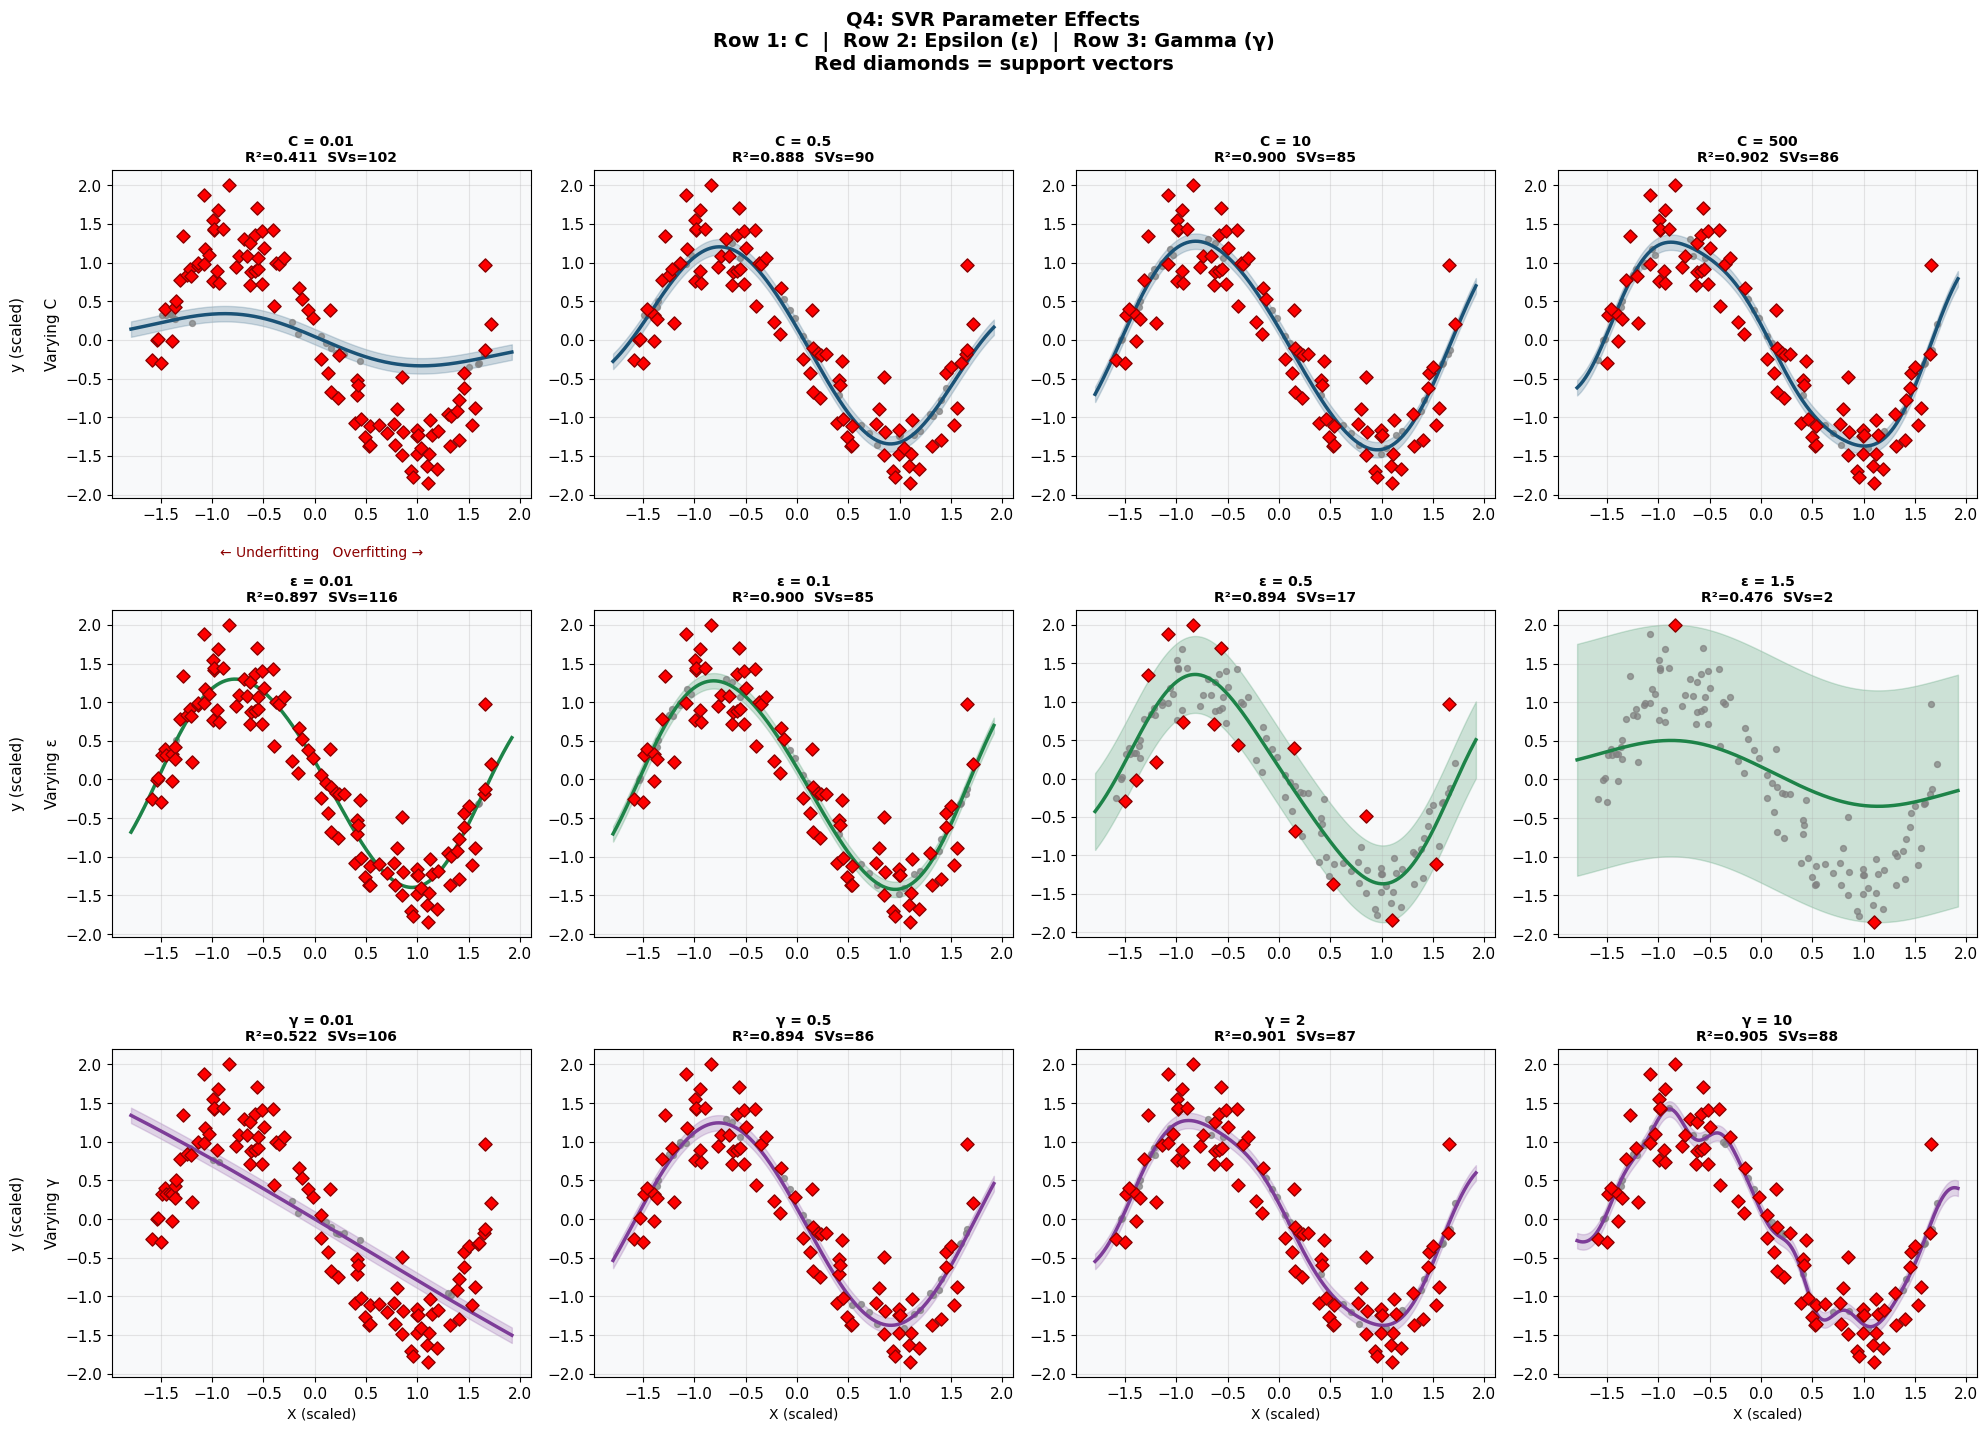

  SVR PARAMETER GUIDE
  Parameter      Effect           Risk                   When to Use
  --------------------------------------------------------------
  C (small)      Wide margin      High bias              Noisy/many outliers
  C (large)      Narrow margin    High variance          Clean, high accuracy needed
  ε (small)      Tight tube       Many SVs, complex      Small errors critical
  ε (large)      Wide tube        Few SVs, simple        Approximate fit OK
  γ (small)      Global/smooth    Underfitting risk      Few features, spread data
  γ (large)      Local/wiggly     Overfitting risk       Dense clusters
Q4 visualisation saved.


In [5]:
# Q4: SVR Parameter Effects — Comprehensive Grid

# Dataset: sinusoidal regression
np.random.seed(SEED)
n = 120
X_q4 = np.sort(np.random.uniform(0, 2*np.pi, n)).reshape(-1,1)
y_q4 = np.sin(X_q4.ravel()) + np.random.normal(0, 0.25, n)

sc_X = StandardScaler(); sc_y = StandardScaler()
X_q4_s = sc_X.fit_transform(X_q4)
y_q4_s = sc_y.fit_transform(y_q4.reshape(-1,1)).ravel()
x_plot  = np.linspace(X_q4_s.min()-0.2, X_q4_s.max()+0.2, 400).reshape(-1,1)

def plot_svr_param(ax, svr, title, colour='steelblue'):
    svr.fit(X_q4_s, y_q4_s)
    y_fit = svr.predict(x_plot)
    y_pred = svr.predict(X_q4_s)
    r2 = r2_score(y_q4_s, y_pred)
    n_sv = len(svr.support_)
    eps = svr.epsilon
    ax.scatter(X_q4_s, y_q4_s, color='gray', s=18, alpha=0.7, zorder=3)
    ax.plot(x_plot, y_fit, color=colour, linewidth=2.5, zorder=5)
    ax.fill_between(x_plot.ravel(), y_fit-eps, y_fit+eps,
                    alpha=0.2, color=colour)
    sv_idx = svr.support_
    ax.scatter(X_q4_s[sv_idx], y_q4_s[sv_idx], color='red',
               s=45, zorder=6, marker='D', edgecolors='darkred', linewidth=1)
    ax.set_title(f'{title}\nR²={r2:.3f}  SVs={n_sv}', fontweight='bold', fontsize=10)

fig, axes = plt.subplots(3, 4, figsize=(20, 14))

# Row 1: Vary C
c_vals = [0.01, 0.5, 10, 500]
for col, c in enumerate(c_vals):
    plot_svr_param(axes[0,col],
                   SVR(kernel='rbf', C=c, epsilon=0.1, gamma='scale'),
                   f'C = {c}', colour='#1A5276')
    if col == 0: axes[0,col].set_ylabel('y (scaled)\n\nVarying C', fontsize=11)
axes[0,0].annotate('← Underfitting   Overfitting →',
                    xy=(0.5, -0.18), xycoords='axes fraction',
                    ha='center', fontsize=10, color='darkred',
                    annotation_clip=False)

#  Row 2: Vary Epsilon
eps_vals = [0.01, 0.1, 0.5, 1.5]
for col, eps in enumerate(eps_vals):
    plot_svr_param(axes[1,col],
                   SVR(kernel='rbf', C=10, epsilon=eps, gamma='scale'),
                   f'ε = {eps}', colour='#1D8348')
    if col == 0: axes[1,col].set_ylabel('y (scaled)\n\nVarying ε', fontsize=11)

#  Row 3: Vary Gamma
gam_vals = [0.01, 0.5, 2, 10]
for col, gam in enumerate(gam_vals):
    plot_svr_param(axes[2,col],
                   SVR(kernel='rbf', C=5, epsilon=0.1, gamma=gam),
                   f'γ = {gam}', colour='#7D3C98')
    if col == 0: axes[2,col].set_ylabel('y (scaled)\n\nVarying γ', fontsize=11)
    axes[2,col].set_xlabel('X (scaled)', fontsize=10)

fig.suptitle('Q4: SVR Parameter Effects\n'
             'Row 1: C  |  Row 2: Epsilon (ε)  |  Row 3: Gamma (γ)\n'
             'Red diamonds = support vectors',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('q4_svr_parameters.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("=" * 65)
print("  SVR PARAMETER GUIDE")
print("=" * 65)
rows = [
    ['C (small)',    'Wide margin', 'High bias', 'Noisy/many outliers'],
    ['C (large)',    'Narrow margin', 'High variance', 'Clean, high accuracy needed'],
    ['ε (small)',    'Tight tube', 'Many SVs, complex', 'Small errors critical'],
    ['ε (large)',    'Wide tube', 'Few SVs, simple', 'Approximate fit OK'],
    ['γ (small)',    'Global/smooth', 'Underfitting risk', 'Few features, spread data'],
    ['γ (large)',    'Local/wiggly', 'Overfitting risk', 'Dense clusters'],
]
print(f"  {'Parameter':<14} {'Effect':<16} {'Risk':<22} {'When to Use'}")
print("  " + "-" * 62)
for r in rows:
    print(f"  {r[0]:<14} {r[1]:<16} {r[2]:<22} {r[3]}")
print("=" * 65)
print("Q4 visualisation saved.")

---
## Q5. End-to-End SVC Pipeline — Wine Quality Classification

### Dataset: Scikit-learn Wine Dataset
- **178 samples**, **13 features** (chemical properties of wine)
- **3 classes**: Class 0, 1, 2 (wine cultivar types)
- Features: alcohol, malic acid, ash, alcalinity, magnesium, phenols, flavanoids, ...

### Pipeline Steps
```
1. Import libraries & load dataset
2. Exploratory Data Analysis (EDA)
3. Train-test split
4. Preprocessing (StandardScaler)
5. Train SVC classifier
6. Predict & evaluate
7. Hyperparameter tuning (GridSearchCV)
8. Train final tuned model on entire dataset
9. Save model to file (joblib)
```

In [6]:
# STEP 1: Import Libraries & Load Dataset

from sklearn.datasets import load_wine

wine    = load_wine()
X_wine  = wine.data
y_wine  = wine.target
feat_names = list(wine.feature_names)
class_names = list(wine.target_names)

df_wine = pd.DataFrame(X_wine, columns=feat_names)
df_wine['target'] = y_wine
df_wine['class']  = [class_names[t] for t in y_wine]

print("═" * 55)
print("   WINE DATASET — OVERVIEW")
print("═" * 55)
print(f"  Shape          : {X_wine.shape}")
print(f"  Classes        : {class_names}")
print(f"  Class counts   : {dict(zip(class_names, np.bincount(y_wine)))}")
print(f"  Features       : {len(feat_names)}")
print(f"  Missing values : {df_wine.isnull().sum().sum()}")
print("═" * 55)
print("\n  First 5 rows:")
df_wine.head()

═══════════════════════════════════════════════════════
   WINE DATASET — OVERVIEW
═══════════════════════════════════════════════════════
  Shape          : (178, 13)
  Classes        : [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
  Class counts   : {np.str_('class_0'): np.int64(59), np.str_('class_1'): np.int64(71), np.str_('class_2'): np.int64(48)}
  Features       : 13
  Missing values : 0
═══════════════════════════════════════════════════════

  First 5 rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


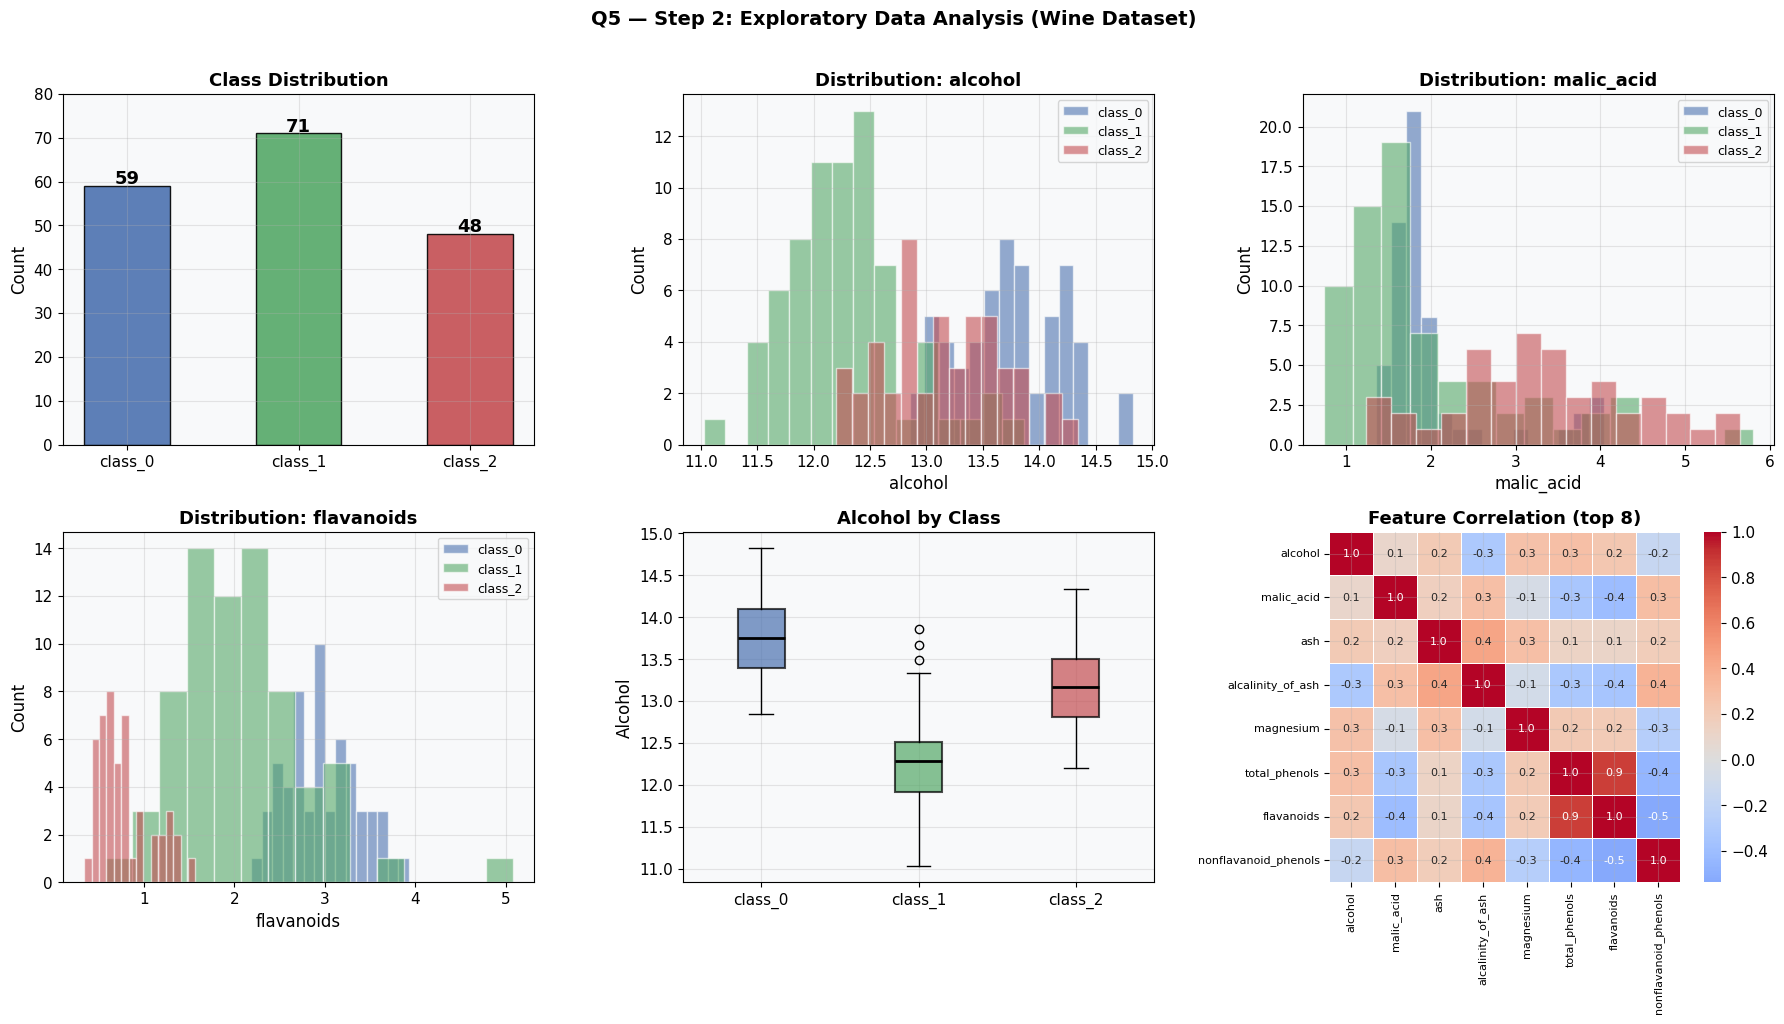

EDA visualisation saved.


In [7]:
# STEP 2: Exploratory Data Analysis (EDA)


fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Class distribution
counts  = np.bincount(y_wine)
colours = ['#4C72B0','#55A868','#C44E52']
bars    = axes[0,0].bar(class_names, counts, color=colours,
                        edgecolor='black', width=0.5, alpha=0.9)
for b, c in zip(bars, counts):
    axes[0,0].text(b.get_x()+b.get_width()/2, c+0.5,
                   str(c), ha='center', fontweight='bold', fontsize=13)
axes[0,0].set_title('Class Distribution', fontweight='bold')
axes[0,0].set_ylabel('Count'); axes[0,0].set_ylim(0, 80)

# Feature distributions (top 4)
selected = ['alcohol', 'malic_acid', 'flavanoids', 'proline']
for idx, feat in enumerate(selected[:3]):
    ax_f = axes[0, idx+1] if idx < 2 else axes[1, 0]
    ax_f = axes[0, 1] if idx==0 else axes[0,2] if idx==1 else axes[1,0]
    for cls, col in zip(range(3), colours):
        data_cls = df_wine[df_wine['target']==cls][feat]
        ax_f.hist(data_cls, bins=15, alpha=0.6, color=col,
                  label=class_names[cls], edgecolor='white')
    ax_f.set_title(f'Distribution: {feat}', fontweight='bold')
    ax_f.set_xlabel(feat); ax_f.set_ylabel('Count')
    ax_f.legend(fontsize=9)

# Boxplot: alcohol by class
bp_data = [df_wine[df_wine['target']==c]['alcohol'].values for c in range(3)]
bp = axes[1,1].boxplot(bp_data, patch_artist=True,
                        boxprops=dict(linewidth=1.5),
                        medianprops=dict(color='black', linewidth=2))
for patch, col in zip(bp['boxes'], colours):
    patch.set_facecolor(col); patch.set_alpha(0.7)
axes[1,1].set_xticklabels(class_names)
axes[1,1].set_title('Alcohol by Class', fontweight='bold')
axes[1,1].set_ylabel('Alcohol')

# Correlation heatmap (top 8 features)
top8 = feat_names[:8]
corr = df_wine[top8].corr()
sns.heatmap(corr, ax=axes[1,2], cmap='coolwarm', center=0,
            annot=True, fmt='.1f', linewidths=0.5,
            annot_kws={'size':8}, square=True)
axes[1,2].set_title('Feature Correlation (top 8)', fontweight='bold')
axes[1,2].tick_params(labelsize=8)

fig.suptitle('Q5 — Step 2: Exploratory Data Analysis (Wine Dataset)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('q5_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA visualisation saved.")

In [8]:
# STEP 3: Train-Test Split


X_tr, X_te, y_tr, y_te = train_test_split(
    X_wine, y_wine,
    test_size=0.25,
    random_state=SEED,
    stratify=y_wine      # preserve class proportions
)

print("═" * 45)
print("  TRAIN-TEST SPLIT")
print("═" * 45)
print(f"  Total samples  : {len(X_wine)}")
print(f"  Train samples  : {len(X_tr)} ({len(X_tr)/len(X_wine)*100:.1f}%)")
print(f"  Test  samples  : {len(X_te)} ({len(X_te)/len(X_wine)*100:.1f}%)")
print(f"  Train class dist: {np.bincount(y_tr)}")
print(f"  Test  class dist: {np.bincount(y_te)}")
print("═" * 45)

═════════════════════════════════════════════
  TRAIN-TEST SPLIT
═════════════════════════════════════════════
  Total samples  : 178
  Train samples  : 133 (74.7%)
  Test  samples  : 45 (25.3%)
  Train class dist: [44 53 36]
  Test  class dist: [15 18 12]
═════════════════════════════════════════════


In [9]:
# STEP 4: Preprocessing — StandardScaler


# Why scaling is CRITICAL for SVM:
# SVM minimises ||w||² and uses dot products — features on very
# different scales dominate the kernel computation.

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)   # fit on train, transform both
X_te_s = scaler.transform(X_te)

print("═" * 55)
print("  PREPROCESSING — StandardScaler")
print("═" * 55)
print(f"  {'Feature':<30} {'Raw Mean':>10} {'Raw Std':>10} {'Scaled Mean':>12} {'Scaled Std':>11}")
print("  " + "-" * 75)
for i, fname in enumerate(feat_names[:6]):
    print(f"  {fname:<30} {X_tr[:,i].mean():>10.3f} {X_tr[:,i].std():>10.3f}"
          f" {X_tr_s[:,i].mean():>12.6f} {X_tr_s[:,i].std():>11.6f}")
print("  ... (showing first 6 of 13 features)")
print("═" * 55)
print("  After scaling: all features have mean≈0, std≈1")

═══════════════════════════════════════════════════════
  PREPROCESSING — StandardScaler
═══════════════════════════════════════════════════════
  Feature                          Raw Mean    Raw Std  Scaled Mean  Scaled Std
  ---------------------------------------------------------------------------
  alcohol                            12.968      0.799     0.000000    1.000000
  malic_acid                          2.333      1.086     0.000000    1.000000
  ash                                 2.368      0.266     0.000000    1.000000
  alcalinity_of_ash                  19.702      3.354     0.000000    1.000000
  magnesium                         100.000     14.926     0.000000    1.000000
  total_phenols                       2.282      0.628     0.000000    1.000000
  ... (showing first 6 of 13 features)
═══════════════════════════════════════════════════════
  After scaling: all features have mean≈0, std≈1


In [10]:
# STEP 5: Train Baseline SVC Classifier


svc_base = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,    # needed for predict_proba
    random_state=SEED
)
svc_base.fit(X_tr_s, y_tr)

print("═" * 45)
print("  BASELINE SVC — TRAINING COMPLETE")
print("═" * 45)
print(f"  Kernel          : {svc_base.kernel}")
print(f"  C               : {svc_base.C}")
print(f"  Gamma           : {svc_base.gamma}")
print(f"  Total SVs       : {svc_base.n_support_.sum()}")
print(f"  SVs per class   : {svc_base.n_support_}")
print("═" * 45)

═════════════════════════════════════════════
  BASELINE SVC — TRAINING COMPLETE
═════════════════════════════════════════════
  Kernel          : rbf
  C               : 1.0
  Gamma           : scale
  Total SVs       : 59
  SVs per class   : [15 27 17]
═════════════════════════════════════════════


═══════════════════════════════════════════════════════
  BASELINE SVC — EVALUATION RESULTS
═══════════════════════════════════════════════════════
  Test Accuracy         : 0.9778
  Weighted Precision    : 0.9789
  Weighted Recall       : 0.9778
  Weighted F1 Score     : 0.9776
  5-Fold CV Accuracy    : 0.9923 ± 0.0154
═══════════════════════════════════════════════════════

  Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       0.95      1.00      0.97        18
     class_2       1.00      0.92      0.96        12

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.98        45
weighted avg       0.98      0.98      0.98        45



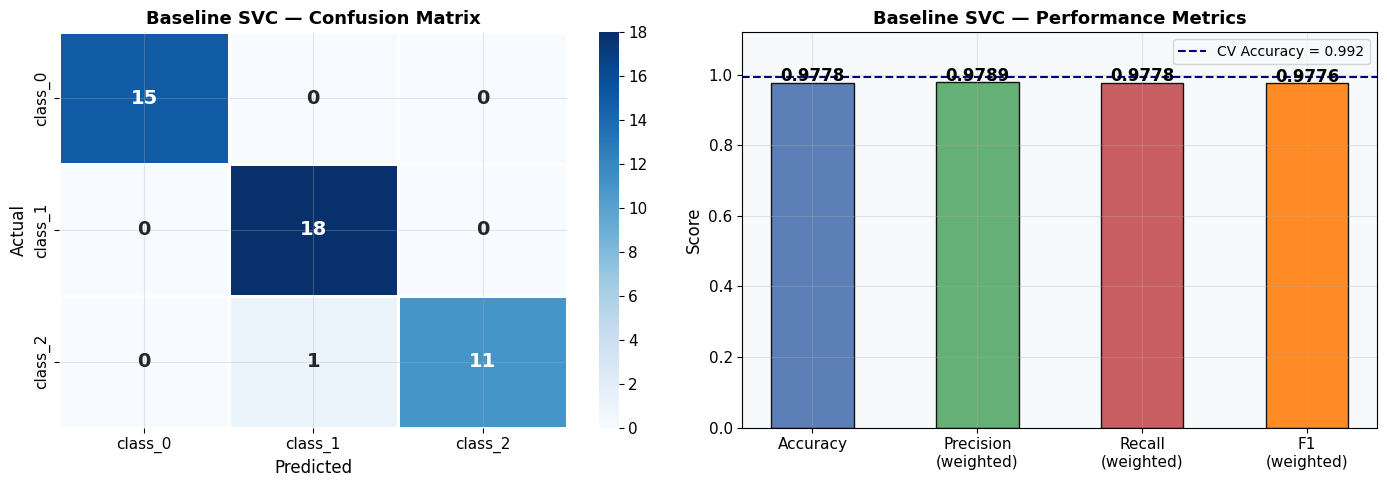

Baseline evaluation visualisation saved.


In [11]:
# STEP 6: Predict & Evaluate


y_pred_base = svc_base.predict(X_te_s)

acc_base  = accuracy_score(y_te, y_pred_base)
prec_base = precision_score(y_te, y_pred_base, average='weighted')
rec_base  = recall_score(y_te, y_pred_base,    average='weighted')
f1_base   = f1_score(y_te, y_pred_base,        average='weighted')

cv_scores = cross_val_score(svc_base, X_tr_s, y_tr, cv=5, scoring='accuracy')

print("═" * 55)
print("  BASELINE SVC — EVALUATION RESULTS")
print("═" * 55)
print(f"  Test Accuracy         : {acc_base:.4f}")
print(f"  Weighted Precision    : {prec_base:.4f}")
print(f"  Weighted Recall       : {rec_base:.4f}")
print(f"  Weighted F1 Score     : {f1_base:.4f}")
print(f"  5-Fold CV Accuracy    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("═" * 55)
print("\n  Classification Report:")
print(classification_report(y_te, y_pred_base, target_names=class_names))

# Visualise confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_base = confusion_matrix(y_te, y_pred_base)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, linecolor='white', annot_kws={'size':14, 'weight':'bold'})
axes[0].set_title('Baseline SVC — Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

# Metrics bar chart
metric_names_b = ['Accuracy','Precision\n(weighted)','Recall\n(weighted)','F1\n(weighted)']
metric_vals_b  = [acc_base, prec_base, rec_base, f1_base]
bar_cols = ['#4C72B0','#55A868','#C44E52','#FF7F0E']
bars_b = axes[1].bar(metric_names_b, metric_vals_b, color=bar_cols,
                     edgecolor='black', width=0.5, alpha=0.9)
for b, v in zip(bars_b, metric_vals_b):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.003,
                 f'{v:.4f}', ha='center', fontweight='bold', fontsize=12)
axes[1].set_ylim(0, 1.12)
axes[1].set_title('Baseline SVC — Performance Metrics', fontweight='bold')
axes[1].set_ylabel('Score', fontsize=12)
axes[1].axhline(cv_scores.mean(), color='navy', linestyle='--', linewidth=1.5,
                label=f'CV Accuracy = {cv_scores.mean():.3f}')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('q5_baseline_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Baseline evaluation visualisation saved.")

In [12]:
# STEP 7: Hyperparameter Tuning with GridSearchCV

param_grid = {
    'C'      : [0.01, 0.1, 1, 10, 50, 100],
    'kernel' : ['rbf', 'linear', 'poly'],
    'gamma'  : ['scale', 'auto', 0.01, 0.1, 1],
    'degree' : [2, 3, 4],   # only for poly kernel
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid_search = GridSearchCV(
    SVC(probability=True, random_state=SEED),
    param_grid,
    cv=cv_strategy,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Running GridSearchCV...")
print(f"  Total combinations : {6*3*5*3} (C×kernel×gamma×degree)")
grid_search.fit(X_tr_s, y_tr)

print("\n═" * 28)
print("  GRIDSEARCHCV RESULTS")
print("═" * 55)
print(f"  Best Parameters   : {grid_search.best_params_}")
print(f"  Best CV Accuracy  : {grid_search.best_score_:.4f}")
print("═" * 55)

Running GridSearchCV...
  Total combinations : 270 (C×kernel×gamma×degree)
Fitting 5 folds for each of 270 candidates, totalling 1350 fits

═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
  GRIDSEARCHCV RESULTS
═══════════════════════════════════════════════════════
  Best Parameters   : {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
  Best CV Accuracy  : 0.9926
═══════════════════════════════════════════════════════


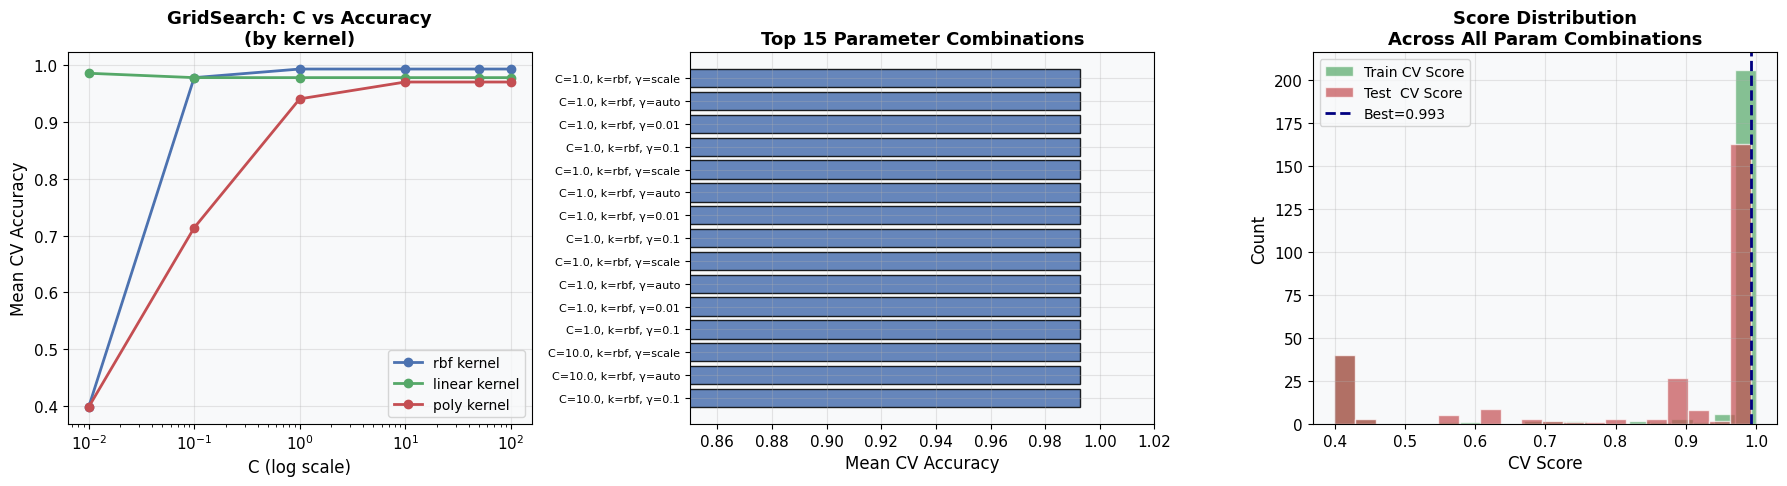

GridSearchCV visualisation saved.


In [13]:
#Visualise GridSearchCV Results

results_df = pd.DataFrame(grid_search.cv_results_)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# C vs CV accuracy by kernel
for kern, col in zip(['rbf','linear','poly'], ['#4C72B0','#55A868','#C44E52']):
    sub = results_df[
        (results_df['param_kernel']==kern) &
        (results_df['param_gamma']=='scale')
    ].copy()
    sub_grp = sub.groupby('param_C')['mean_test_score'].max().reset_index()
    if len(sub_grp) > 0:
        axes[0].plot(sub_grp['param_C'], sub_grp['mean_test_score'],
                     marker='o', linewidth=2, color=col, label=f'{kern} kernel')
axes[0].set_xscale('log')
axes[0].set_xlabel('C (log scale)', fontsize=12)
axes[0].set_ylabel('Mean CV Accuracy', fontsize=12)
axes[0].set_title('GridSearch: C vs Accuracy\n(by kernel)', fontweight='bold')
axes[0].legend(fontsize=10)

# Best 15 parameter combinations
top15 = results_df.nlargest(15, 'mean_test_score')
top15_labels = [f"C={r['param_C']}, k={r['param_kernel'][:3]}, γ={str(r['param_gamma'])[:5]}"
                for _, r in top15.iterrows()]
axes[1].barh(range(15), top15['mean_test_score'].values,
             color='#4C72B0', edgecolor='black', alpha=0.85)
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(top15_labels, fontsize=8)
axes[1].set_xlabel('Mean CV Accuracy', fontsize=12)
axes[1].set_title('Top 15 Parameter Combinations', fontweight='bold')
axes[1].invert_yaxis()
axes[1].set_xlim(0.85, 1.02)

# Train vs test score distribution
axes[2].hist(results_df['mean_train_score'], bins=20, alpha=0.7,
             color='#55A868', label='Train CV Score', edgecolor='white')
axes[2].hist(results_df['mean_test_score'],  bins=20, alpha=0.7,
             color='#C44E52', label='Test  CV Score', edgecolor='white')
axes[2].axvline(grid_search.best_score_, color='navy', linestyle='--',
                linewidth=2, label=f'Best={grid_search.best_score_:.3f}')
axes[2].set_xlabel('CV Score', fontsize=12)
axes[2].set_ylabel('Count', fontsize=12)
axes[2].set_title('Score Distribution\nAcross All Param Combinations', fontweight='bold')
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.savefig('q5_gridsearch.png', dpi=150, bbox_inches='tight')
plt.show()
print("GridSearchCV visualisation saved.")

═══════════════════════════════════════════════════════
  TUNED SVC — TRAINED ON FULL DATASET
═══════════════════════════════════════════════════════
  Best Parameters  : {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
  Total SVs        : 69
───────────────────────────────────────────────────────
  Test Accuracy    : 1.0000  (baseline: 0.9778)
  Test Precision   : 1.0000  (baseline: 0.9789)
  Test Recall      : 1.0000  (baseline: 0.9778)
  Test F1 Score    : 1.0000  (baseline: 0.9776)
═══════════════════════════════════════════════════════

  Classification Report (Tuned):
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      1.00      1.00        18
     class_2       1.00      1.00      1.00        12

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



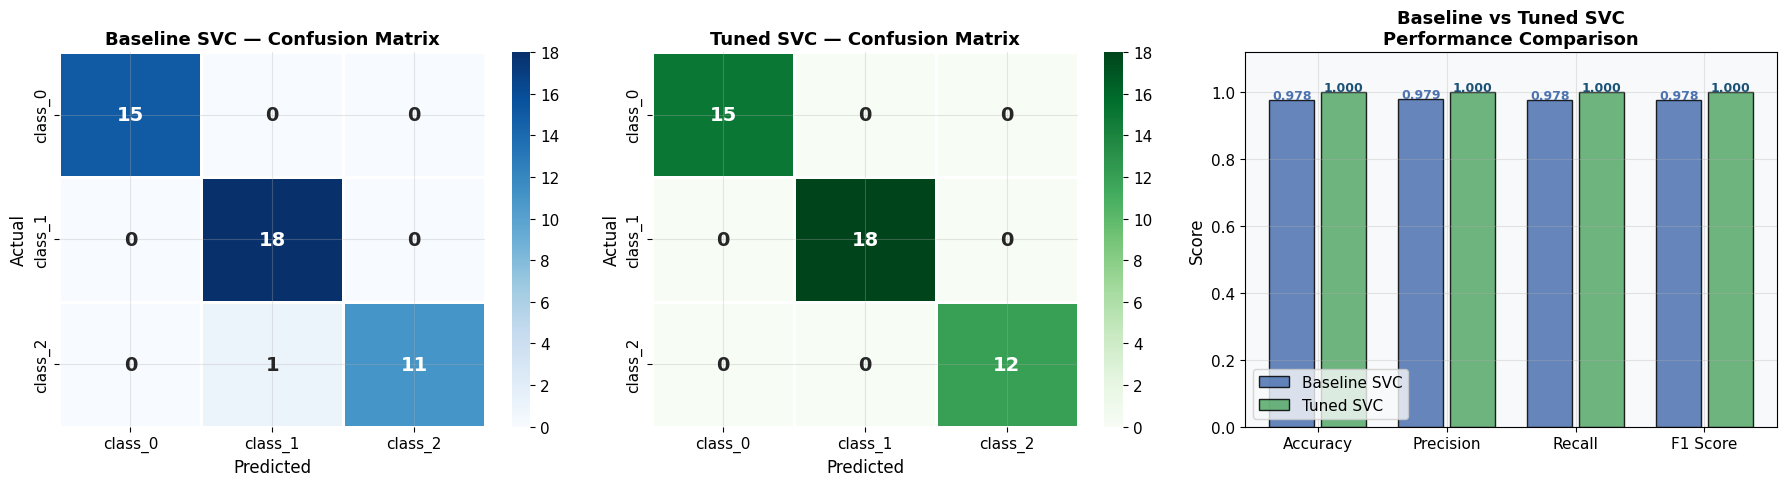

Tuned model comparison visualisation saved.


In [14]:
# STEP 8: Train Tuned Classifier on ENTIRE Dataset

best_params = grid_search.best_params_

# Scale entire dataset
scaler_full = StandardScaler()
X_full_s    = scaler_full.fit_transform(X_wine)

# Tuned SVC
svc_tuned = SVC(**best_params, probability=True, random_state=SEED)
svc_tuned.fit(X_full_s, y_wine)

# Final test evaluation (on held-out test set)
X_te_best = scaler_full.transform(X_te)   # use full-data scaler for test
y_pred_tuned = svc_tuned.predict(X_te_best)

acc_tuned  = accuracy_score(y_te, y_pred_tuned)
prec_tuned = precision_score(y_te, y_pred_tuned, average='weighted')
rec_tuned  = recall_score(y_te, y_pred_tuned,    average='weighted')
f1_tuned   = f1_score(y_te, y_pred_tuned,        average='weighted')

print("═" * 55)
print("  TUNED SVC — TRAINED ON FULL DATASET")
print("═" * 55)
print(f"  Best Parameters  : {best_params}")
print(f"  Total SVs        : {svc_tuned.n_support_.sum()}")
print("─" * 55)
print(f"  Test Accuracy    : {acc_tuned:.4f}  (baseline: {acc_base:.4f})")
print(f"  Test Precision   : {prec_tuned:.4f}  (baseline: {prec_base:.4f})")
print(f"  Test Recall      : {rec_tuned:.4f}  (baseline: {rec_base:.4f})")
print(f"  Test F1 Score    : {f1_tuned:.4f}  (baseline: {f1_base:.4f})")
print("═" * 55)
print("\n  Classification Report (Tuned):")
print(classification_report(y_te, y_pred_tuned, target_names=class_names))

# Comparison visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrices
for ax_idx, (title, y_pred, cmap_name) in enumerate([
    ('Baseline SVC', y_pred_base, 'Blues'),
    ('Tuned SVC',    y_pred_tuned, 'Greens')
]):
    cm_plot = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm_plot, annot=True, fmt='d', cmap=cmap_name,
                ax=axes[ax_idx],
                xticklabels=class_names, yticklabels=class_names,
                linewidths=1, linecolor='white',
                annot_kws={'size':14, 'weight':'bold'})
    axes[ax_idx].set_title(f'{title} — Confusion Matrix', fontweight='bold')
    axes[ax_idx].set_ylabel('Actual', fontsize=12)
    axes[ax_idx].set_xlabel('Predicted', fontsize=12)

# Side-by-side metric comparison
metrics_comp = ['Accuracy','Precision','Recall','F1 Score']
base_vals_c  = [acc_base, prec_base, rec_base, f1_base]
tuned_vals_c = [acc_tuned, prec_tuned, rec_tuned, f1_tuned]
x5 = np.arange(len(metrics_comp))
axes[2].bar(x5-0.2, base_vals_c,  0.35, label='Baseline SVC',
            color='#4C72B0', edgecolor='black', alpha=0.85)
axes[2].bar(x5+0.2, tuned_vals_c, 0.35, label='Tuned SVC',
            color='#55A868', edgecolor='black', alpha=0.85)
for i, (b, t) in enumerate(zip(base_vals_c, tuned_vals_c)):
    axes[2].text(i-0.2, b+0.003, f'{b:.3f}', ha='center',
                 fontsize=9, fontweight='bold', color='#4C72B0')
    axes[2].text(i+0.2, t+0.003, f'{t:.3f}', ha='center',
                 fontsize=9, fontweight='bold', color='#1A5276')
axes[2].set_xticks(x5); axes[2].set_xticklabels(metrics_comp, fontsize=11)
axes[2].set_ylim(0, 1.12)
axes[2].set_ylabel('Score', fontsize=12)
axes[2].set_title('Baseline vs Tuned SVC\nPerformance Comparison', fontweight='bold')
axes[2].legend(fontsize=11)

plt.tight_layout()
plt.savefig('q5_tuned_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Tuned model comparison visualisation saved.")

In [15]:
# STEP 9: Save Trained Classifier to File


import joblib

# Save model components
model_path  = 'svc_wine_tuned.pkl'
scaler_path = 'scaler_wine.pkl'

joblib.dump(svc_tuned,    model_path)
joblib.dump(scaler_full,  scaler_path)

print("═" * 50)
print("  MODEL SAVED SUCCESSFULLY")
print("═" * 50)
print(f"  Classifier : {model_path}")
print(f"  Scaler     : {scaler_path}")
print(f"  Size       : {os.path.getsize(model_path):,} bytes")

# ── Verification: Load and predict ──
loaded_model  = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)

# Sample predictions
sample_raw = X_wine[:5]
sample_s   = loaded_scaler.transform(sample_raw)
sample_pred = loaded_model.predict(sample_s)
sample_prob = loaded_model.predict_proba(sample_s)

print("\n  Verification — Predict 5 samples from loaded model:")
print(f"  {'#':<4} {'True Label':<14} {'Predicted':<14} {'Max Confidence'}")
print("  " + "-" * 48)
for i in range(5):
    true  = class_names[y_wine[i]]
    pred  = class_names[sample_pred[i]]
    conf  = sample_prob[i].max()
    match = '✓' if true == pred else '✗'
    print(f"  {i:<4} {true:<14} {pred:<14} {conf:.4f}  {match}")
print("═" * 50)
print("  Model loaded and verified successfully!")
print("═" * 50)

══════════════════════════════════════════════════
  MODEL SAVED SUCCESSFULLY
══════════════════════════════════════════════════
  Classifier : svc_wine_tuned.pkl
  Scaler     : scaler_wine.pkl
  Size       : 11,427 bytes

  Verification — Predict 5 samples from loaded model:
  #    True Label     Predicted      Max Confidence
  ------------------------------------------------
  0    class_0        class_0        0.9892  ✓
  1    class_0        class_0        0.9765  ✓
  2    class_0        class_0        0.9902  ✓
  3    class_0        class_0        0.9629  ✓
  4    class_0        class_0        0.9686  ✓
══════════════════════════════════════════════════
  Model loaded and verified successfully!
══════════════════════════════════════════════════


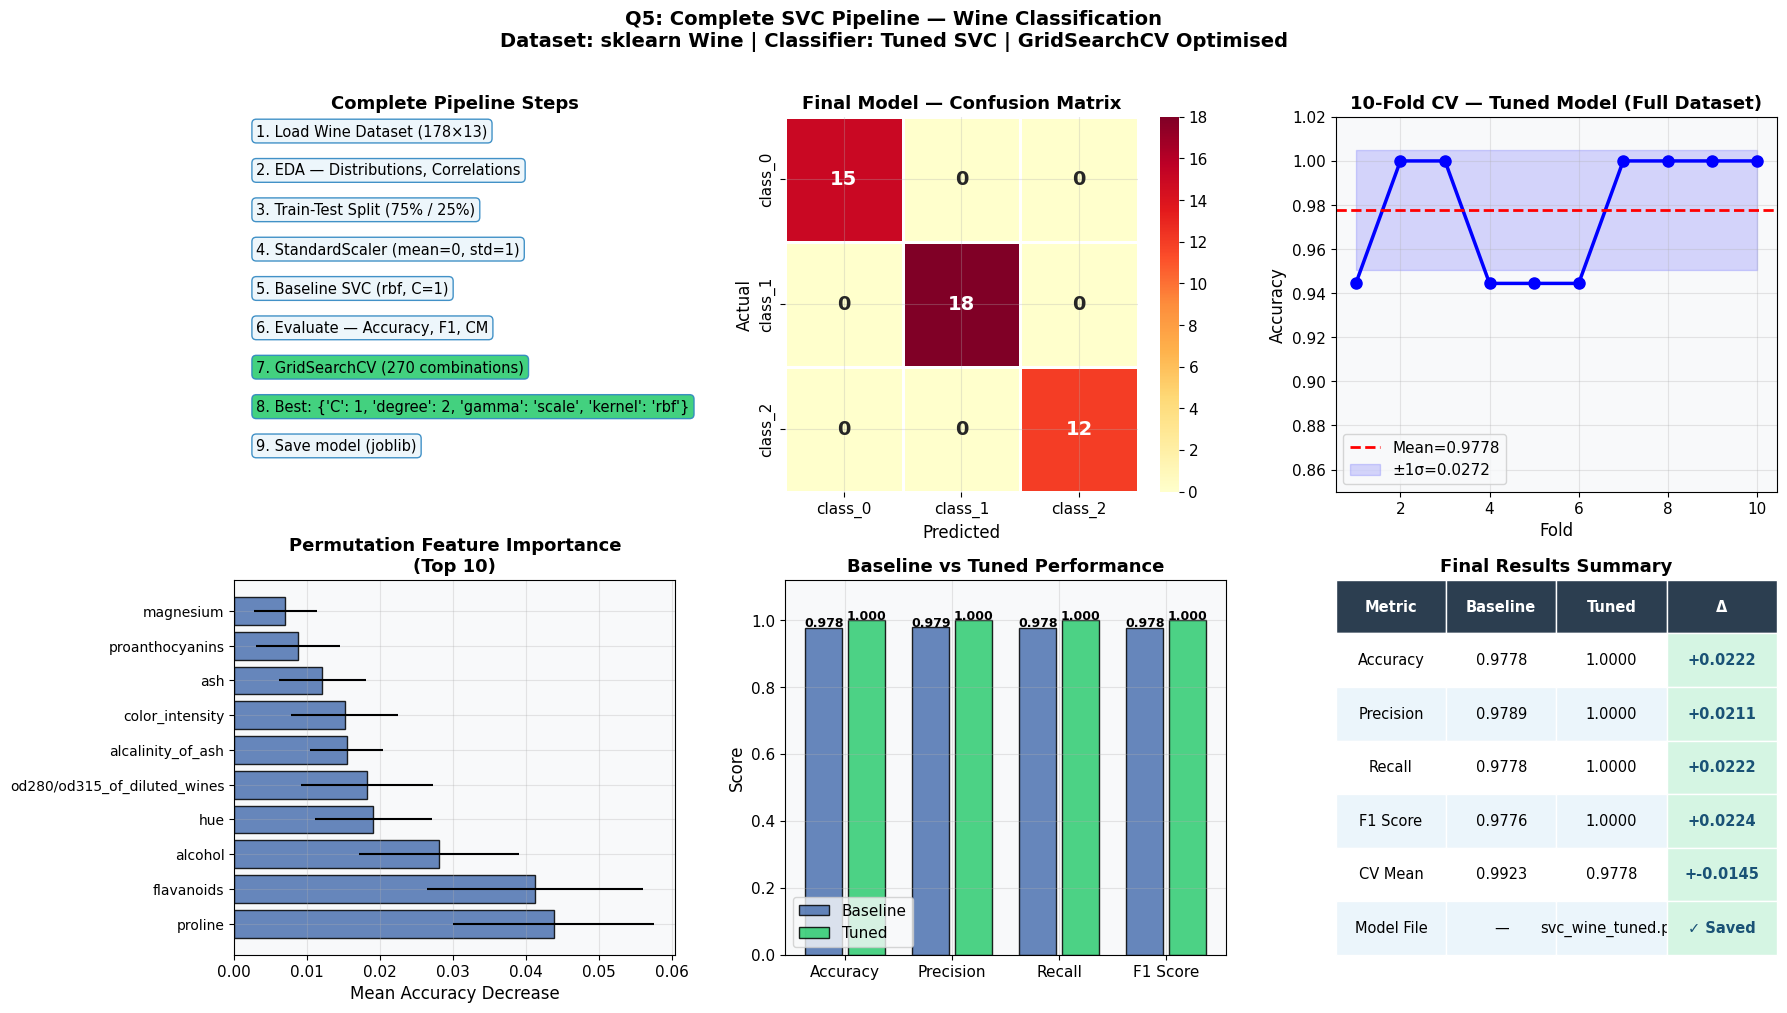

In [16]:
# FINAL SUMMARY DASHBOARD

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Pipeline flowchart (text-based)
axes[0,0].axis('off')
steps = [
    '1. Load Wine Dataset (178×13)',
    '2. EDA — Distributions, Correlations',
    '3. Train-Test Split (75% / 25%)',
    '4. StandardScaler (mean=0, std=1)',
    '5. Baseline SVC (rbf, C=1)',
    '6. Evaluate — Accuracy, F1, CM',
    '7. GridSearchCV (270 combinations)',
    f'8. Best: {best_params}',
    '9. Save model (joblib)',
]
y_pos = 0.95
for step in steps:
    colour = '#2ECC71' if step.startswith('7') or step.startswith('8') else '#EBF5FB'
    axes[0,0].text(0.05, y_pos, step, transform=axes[0,0].transAxes,
                   fontsize=10.5,
                   bbox=dict(boxstyle='round,pad=0.3', facecolor=colour,
                             edgecolor='#2E86C1', alpha=0.9))
    y_pos -= 0.105
axes[0,0].set_title('Complete Pipeline Steps', fontweight='bold', fontsize=13)

# 2. Final confusion matrix
cm_final = confusion_matrix(y_te, y_pred_tuned)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='YlOrRd',
            ax=axes[0,1],
            xticklabels=class_names, yticklabels=class_names,
            linewidths=2, linecolor='white',
            annot_kws={'size':14, 'weight':'bold'})
axes[0,1].set_title('Final Model — Confusion Matrix', fontweight='bold')
axes[0,1].set_ylabel('Actual', fontsize=12)
axes[0,1].set_xlabel('Predicted', fontsize=12)

# 3. CV score distribution
cv_final = cross_val_score(svc_tuned, X_full_s, y_wine, cv=10, scoring='accuracy')
axes[0,2].plot(range(1,11), cv_final, 'bo-', linewidth=2.5, markersize=8)
axes[0,2].axhline(cv_final.mean(), color='red', linestyle='--', linewidth=2,
                  label=f'Mean={cv_final.mean():.4f}')
axes[0,2].fill_between(range(1,11),
                       cv_final.mean()-cv_final.std(),
                       cv_final.mean()+cv_final.std(),
                       alpha=0.15, color='blue', label=f'±1σ={cv_final.std():.4f}')
axes[0,2].set_xlabel('Fold', fontsize=12)
axes[0,2].set_ylabel('Accuracy', fontsize=12)
axes[0,2].set_title('10-Fold CV — Tuned Model (Full Dataset)', fontweight='bold')
axes[0,2].legend(fontsize=11)
axes[0,2].set_ylim(0.85, 1.02)

# 4. Feature importance proxy (SVM coefficients not directly available,
#    use permutation importance)
from sklearn.inspection import permutation_importance
perm = permutation_importance(svc_tuned, X_full_s, y_wine,
                              n_repeats=20, random_state=SEED)
imp_idx  = perm.importances_mean.argsort()[::-1][:10]
axes[1,0].barh(range(10), perm.importances_mean[imp_idx][::-1],
               xerr=perm.importances_std[imp_idx][::-1],
               color='#4C72B0', edgecolor='black', alpha=0.85)
axes[1,0].set_yticks(range(10))
axes[1,0].set_yticklabels([feat_names[i] for i in imp_idx[::-1]], fontsize=10)
axes[1,0].set_xlabel('Mean Accuracy Decrease', fontsize=12)
axes[1,0].set_title('Permutation Feature Importance\n(Top 10)', fontweight='bold')
axes[1,0].invert_yaxis()

# 5. Baseline vs Tuned comparison
comp_metrics = ['Accuracy','Precision','Recall','F1 Score']
comp_base    = [acc_base,  prec_base,  rec_base,  f1_base]
comp_tuned   = [acc_tuned, prec_tuned, rec_tuned, f1_tuned]
xc = np.arange(4)
axes[1,1].bar(xc-0.2, comp_base,  0.35, label='Baseline', color='#4C72B0',
              edgecolor='black', alpha=0.85)
axes[1,1].bar(xc+0.2, comp_tuned, 0.35, label='Tuned',    color='#2ECC71',
              edgecolor='black', alpha=0.85)
for i, (b, t) in enumerate(zip(comp_base, comp_tuned)):
    axes[1,1].text(i-0.2, b+0.003, f'{b:.3f}', ha='center', fontsize=9, fontweight='bold')
    axes[1,1].text(i+0.2, t+0.003, f'{t:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[1,1].set_xticks(xc); axes[1,1].set_xticklabels(comp_metrics, fontsize=11)
axes[1,1].set_ylim(0, 1.12); axes[1,1].set_ylabel('Score', fontsize=12)
axes[1,1].set_title('Baseline vs Tuned Performance', fontweight='bold')
axes[1,1].legend(fontsize=11)

# 6. Summary table
axes[1,2].axis('off')
summary_data = [
    ['Metric', 'Baseline', 'Tuned', 'Δ'],
    ['Accuracy',  f'{acc_base:.4f}',  f'{acc_tuned:.4f}',
     f'+{acc_tuned-acc_base:.4f}'],
    ['Precision', f'{prec_base:.4f}', f'{prec_tuned:.4f}',
     f'+{prec_tuned-prec_base:.4f}'],
    ['Recall',    f'{rec_base:.4f}',  f'{rec_tuned:.4f}',
     f'+{rec_tuned-rec_base:.4f}'],
    ['F1 Score',  f'{f1_base:.4f}',   f'{f1_tuned:.4f}',
     f'+{f1_tuned-f1_base:.4f}'],
    ['CV Mean',   f'{cv_scores.mean():.4f}', f'{cv_final.mean():.4f}',
     f'+{cv_final.mean()-cv_scores.mean():.4f}'],
    ['Model File', '—', 'svc_wine_tuned.pkl', '✓ Saved'],
]
tbl = axes[1,2].table(cellText=summary_data[1:], colLabels=summary_data[0],
                      cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False); tbl.set_fontsize(10.5)
for (r,c), cell in tbl.get_celld().items():
    if r==0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif c==3:
        cell.set_facecolor('#D5F5E3')
        cell.set_text_props(color='#1A5276', fontweight='bold')
    elif r%2==0: cell.set_facecolor('#EBF5FB')
    cell.set_edgecolor('white')
axes[1,2].set_title('Final Results Summary', fontweight='bold', fontsize=13)

fig.suptitle('Q5: Complete SVC Pipeline — Wine Classification\n'
             'Dataset: sklearn Wine | Classifier: Tuned SVC | GridSearchCV Optimised',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('q5_final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

